In [1]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure Eigen headers are discoverable for optional C++ extension build
for _cand in (
    "/usr/include/eigen3",
    "/usr/local/include/eigen3",
    str(Path.home() / ".local" / "eigen-src" / "eigen-3.4.0"),
):
    if os.path.isfile(f"{_cand}/Eigen/Core"):
        os.environ.setdefault("EIGEN_INCLUDE", _cand)
        break

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse
from negf import sancho_rubio_iterative_greens_function
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )



# Load channel

Loaded dataset: TB_silicon_nw
H_device shape: (640, 640), S_device shape: (640, 640)
Central region atoms: 128


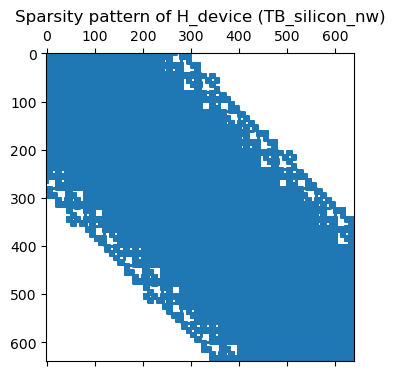

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load silicon nanowire TB dataset
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()

# Core NEGF inputs
energy = np.load(_data_dir / "Energy_grid.npy")
energy_abs_ref = np.load(_data_dir / "Energy_grid_absolute.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")

# Structure metadata requested by you
central_coords_angstrom = np.load(_data_dir / "central_coords_angstrom.npy")
central_elements = np.load(_data_dir / "central_elements.npy")
atom_offsets = np.load(_data_dir / "atom_offsets.npy")

# Optional DOS reference exported by ATK
dos_energy_rel_ref = np.load(_data_dir / "DOS_energies_relative.npy")
dos_total_ref = np.load(_data_dir / "DOS_total.npy")

# Quick sanity checks
print(f"Loaded dataset: {_data_dir.name}")
print(f"H_device shape: {H_device.shape}, S_device shape: {S_device.shape}")
print(f"Central region atoms: {len(central_elements)}")

# Visual check of sparsity
plt.figure(figsize=(5, 4))
plt.spy(H_device, markersize=1)
plt.title("Sparsity pattern of H_device (TB_silicon_nw)")
plt.show()

## determine equilibrium fermi energy

In [3]:
# --- Build electron count + geometry metadata from dataset arrays ---

# Valence model (symbols + atomic numbers)
_valence_by_symbol = {
    "H": 1.0,
    "C": 4.0,
    "Si": 4.0,
}
_valence_by_Z = {
    1: 1.0,
    6: 4.0,
    14: 4.0,
}

elements = np.asarray(central_elements)
if elements.dtype.kind in {"U", "S", "O"}:
    elements_norm = np.array([str(x) for x in elements])
    unique_el, counts_el = np.unique(elements_norm, return_counts=True)
    missing = [el for el in unique_el if el not in _valence_by_symbol]
    if missing:
        raise ValueError(f"Missing valence mapping for element symbols: {missing}")
    N_val = int(round(sum(_valence_by_symbol[el] * int(c) for el, c in zip(unique_el, counts_el))))
    element_summary = dict(zip(unique_el.tolist(), counts_el.tolist()))
else:
    elements_Z = elements.astype(int)
    unique_Z, counts_Z = np.unique(elements_Z, return_counts=True)
    missing = [int(Z) for Z in unique_Z if int(Z) not in _valence_by_Z]
    if missing:
        raise ValueError(f"Missing valence mapping for atomic numbers: {missing}")
    N_val = int(round(sum(_valence_by_Z[int(Z)] * int(c) for Z, c in zip(unique_Z, counts_Z))))
    element_summary = dict(zip(unique_Z.tolist(), counts_Z.tolist()))

# Geometry info from central_coords_angstrom.npy
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

N_val = N_val

print("--- TB_silicon_nw metadata ---")
print(f"Elements in central region: {element_summary}")
print(f"Valence electrons (N_val): {N_val}")
print(f"H_device orbitals: {H_device.shape[0]}")
print(f"Central coordinates span [Å]: x={span[0]:.3f}, y={span[1]:.3f}, z={span[2]:.3f}")
print(f"atom_offsets length: {len(atom_offsets)}")

--- TB_silicon_nw metadata ---
Elements in central region: {'H': 64, 'Si': 64}
Valence electrons (N_val): 320
H_device orbitals: 640
Central coordinates span [Å]: x=8.177, y=8.177, z=21.371
atom_offsets length: 65


In [4]:
# Build lead principal-layer blocks once
nL = sigma_L_ref.shape[1]
H00_L = H_device[:nL, :nL]
S00_L = S_device[:nL, :nL]
H01_L = H_device[:nL, nL:2*nL]
H10_L = H_device[nL:2*nL, :nL]
S01_L = S_device[:nL, nL:2*nL]
S10_L = S_device[nL:2*nL, :nL]

H00_R = H_device[-nL:, -nL:]
S00_R = S_device[-nL:, -nL:]
H01_R = H_device[-nL:, -2*nL:-nL]
H10_R = H_device[-2*nL:-nL, -nL:]
S01_R = S_device[-nL:, -2*nL:-nL]
S10_R = S_device[-2*nL:-nL, -nL:]

In [ ]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from negf.gf.recursive_greens_functions import _recursive_inverse

_eta = 1e-6
_damp = 1e-6
_tol = 1e-10


# Wide integration window to capture deep valence states
E_grid = np.linspace(-17.0, 2.0, 1201)

print(f"Computing DOS on wide grid ({len(E_grid)} points) ...")
print(f"Energy window: [{E_grid[0]:.6f}, {E_grid[-1]:.6f}] eV")
print(f"Lead block size: {nL}, Device size: {H_device.shape[0]}")


def _dos_one(i):
    E = float(E_grid[i])

    sigL = sancho_rubio_iterative_greens_function(
        E, h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=_damp, nconv=_tol,
    )
    sigR = sancho_rubio_iterative_greens_function(
        E, h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=_damp, nconv=_tol,
    )

    res = _recursive_inverse(
        E, H_device, sigL, sigR,
        compute_lesser=False,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=True,
        return_diag=False,
        return_gamma=False,
    )

    return float(-np.imag(res[-1]) / np.pi)

_nproc = 16
_ctx = mp.get_context("fork")
with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
    dos_list = list(ex.map(_dos_one, range(len(E_grid)), chunksize=max(1, len(E_grid)//(_nproc*4))))

dos_negf = np.array(dos_list, dtype=float)
print("Done.")

Computing DOS on wide grid (1201 points) ...
Energy window: [-17.000000, 2.000000] eV
Lead block size: 160, Device size: 640
Done.


Ev = -5.837500 eV
Ec = -2.797500 eV
Ef = (Ec + Ev)/2 = -4.317500 eV


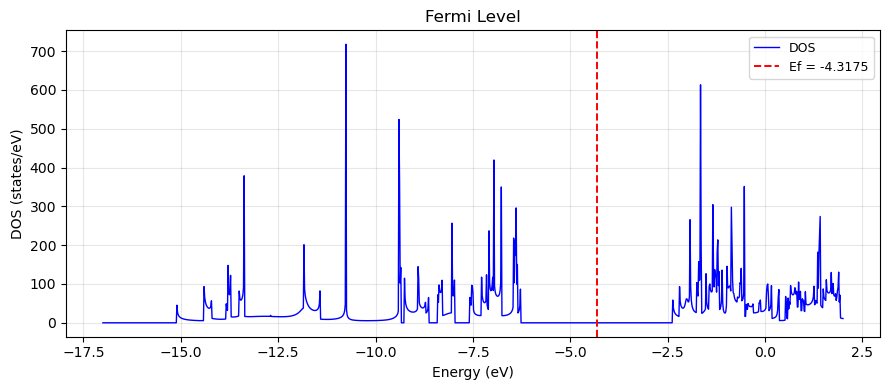

In [31]:
# Ef = (Ec + Ev)/2

# Light smoothing so edge detection is stable
win = 11
kernel = np.ones(win, dtype=float) / win
dos_smooth = np.convolve(dos_negf, kernel, mode="same")

# Low-DOS threshold for gap detection
thresh = min(np.percentile(dos_smooth, 25), 0.05 * float(np.max(dos_smooth)))
low = dos_smooth <= thresh

# Find contiguous low-DOS segments
segments = []
in_seg = False
start = 0
for i, flag in enumerate(low):
    if flag and not in_seg:
        start = i
        in_seg = True
    elif not flag and in_seg:
        segments.append((start, i - 1))
        in_seg = False
if in_seg:
    segments.append((start, len(low) - 1))

# Use widest interior gap
n = len(E_grid)
interior = [(a, b) for (a, b) in segments if a > int(0.03 * n) and b < int(0.97 * n)]
if not interior:
    raise RuntimeError("No interior bandgap found.")

a, b = max(interior, key=lambda t: t[1] - t[0])
Ev = float(E_grid[a - 1])
Ec = float(E_grid[b + 1])
Ef_negf = 0.5 * (Ev + Ec)

print(f"Ev = {Ev:.6f} eV")
print(f"Ec = {Ec:.6f} eV")
print(f"Ef = (Ec + Ev)/2 = {Ef_negf:.6f} eV")

# Simple plot
plt.figure(figsize=(9, 4))
plt.plot(E_grid, 2 * dos_negf, "b-", lw=1, label="DOS")
# plt.axvline(Ev, color="purple", ls="-.", lw=1.2, label=f"Ev = {Ev:.4f}")
# plt.axvline(Ec, color="green", ls="-.", lw=1.2, label=f"Ec = {Ec:.4f}")
plt.axvline(Ef_negf, color="r", ls="--", lw=1.4, label=f"Ef = {Ef_negf:.4f}")
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")
plt.title("Fermi Level")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# define device

In [25]:
Ef0 = -4.317500
Ev0 = -5.837500
Ec0 = -2.797500

# scaling
V_0 = 0.026          # voltage scale (V)
L_0 = 1.0e-10        # length scale (m), i.e. 1 Å
N_0 = 1e24           # density scale (m^-3)

# doping
Nd_physical_val = 1.0e26  # 1e20 cm^-3 (Source/Drain)
ni_physical_val = 1.0e16
#Na_physical_val = 2.0e23  # 2e17 cm^-3 (Bulk)
Nd_val = Nd_physical_val / N_0
#Na_val = Na_physical_val / N_0
phi_bi = V_0 * np.log(Nd_physical_val / ni_physical_val)


# constants
q = 1.609e-19
eps_0 = 8.854e-12
poisson_coeff = (q * N_0 * (L_0**2)) / (eps_0 * V_0)

# junction size from channel geometry (central region), in Angstrom
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

Lx = float(span[0])
Ly = float(span[1])
Lz = float(span[2])

# normalized dimensions: since L_0 = 1 Å, these are numerically equal to Lx/Ly/Lz in Å
x_dim = Lx
y_dim = Ly
z_dim = Lz

Nx = 100
Ny = 30
Nz = 30

# material property
eps_si_rel = 11.7

V_applied_left = 0.1 + phi_bi
V_applied_right = 0 + phi_bi
psi_left_norm = V_applied_left / V_0
psi_right_norm = V_applied_right / V_0

print(f"Lx={Lx:.3f} Å, Ly={Ly:.3f} Å, Lz={Lz:.3f} Å")
print(f"normalized box: x_dim={x_dim:.3f}, y_dim={y_dim:.3f}, z_dim={z_dim:.3f}")
print(f"poisson_coeff={poisson_coeff:.6e}")

print(f"Calculated Built-in Potential (Source): {phi_bi:.4f} V")
print(f"Normalized Source BC (psi_left_norm): {psi_left_norm:.4f}")

Lx=8.177 Å, Ly=8.177 Å, Lz=21.371 Å
normalized box: x_dim=8.177, y_dim=8.177, z_dim=21.371
poisson_coeff=6.989453e-03
Calculated Built-in Potential (Source): 0.5987 V
Normalized Source BC (psi_left_norm): 26.8720


# define mesh

In [26]:
from mpi4py import MPI
from dolfinx import mesh
from dolfinx import fem
import ufl
from dolfinx import default_scalar_type
from dolfinx.fem.petsc import LinearProblem
import pyvista
import pyvista as pv
from dolfinx import plot

pyvista.set_jupyter_backend("static")
pyvista.start_xvfb()

# 3D domain (box): [0,0,0] to [x_dim, y_dim, z_dim]
domain = mesh.create_box(
    MPI.COMM_WORLD,
    [[0.0, 0.0, 0.0], [x_dim, y_dim, z_dim]],
    [Nx, Ny, Nz],
    cell_type=mesh.CellType.tetrahedron,
)


/home/nandan_diwan/.conda/envs/negf_env/lib/python3.11/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


In [7]:
V = fem.functionspace(domain, ("Lagrange", 1)) # this is the potential transformation space
Q = fem.functionspace(domain, ("DG", 0)) # this is piece wise 

# translation from FEM grid to atomistic grid

In [ ]:
from scipy.spatial import cKDTree
from dolfinx import geometry as dfx_geom


class AtomFEMTranslator:
    """Bi-directional translator between atomistic (NEGF) and FEM (dolfinx) grids.

    Atom → FEM:  Gaussian smearing of per-atom scalar values onto DG0 cell grid.
    FEM  → Atom: Point evaluation of a dolfinx Function at atom positions (pooling).

    Parameters
    ----------
    atom_coords_mesh : (N_atoms, 3) ndarray
        Atom positions in the mesh coordinate frame (origin at [0,0,0]).
    domain : dolfinx.mesh.Mesh
    n_orbitals : int
        Total number of orbitals (H_device.shape[0]).
    orbs_per_atom : int or (N_atoms,) array
        Number of basis orbitals per atom.  Scalar → uniform.
    sigma : float or None
        Gaussian smearing width (Å).  If None, median nearest-neighbour distance.
    """

    def __init__(self, atom_coords_mesh, domain, n_orbitals,
                 orbs_per_atom=None, sigma=None):

        self.coords = np.asarray(atom_coords_mesh, dtype=np.float64)
        self.n_atoms = len(self.coords)
        self.n_orbitals = n_orbitals

        # ---- orbital <-> atom mapping ----
        if orbs_per_atom is None:
            orbs_per_atom = n_orbitals // self.n_atoms
        if np.isscalar(orbs_per_atom):
            orbs_per_atom = np.full(self.n_atoms, int(orbs_per_atom), dtype=int)
        self._orbs_per_atom = np.asarray(orbs_per_atom, dtype=int)
        assert self._orbs_per_atom.sum() == n_orbitals, \
            f"sum(orbs_per_atom)={self._orbs_per_atom.sum()} != n_orbitals={n_orbitals}"

        # cumulative offsets  (length n_atoms + 1)
        self.offsets = np.concatenate(([0], np.cumsum(self._orbs_per_atom)))

        # flat array: orbital index → atom index  (for np.bincount)
        self.orbital_to_atom = np.zeros(n_orbitals, dtype=int)
        for j in range(self.n_atoms):
            self.orbital_to_atom[self.offsets[j]:self.offsets[j + 1]] = j

        # ---- Gaussian sigma ----
        if sigma is None:
            tree = cKDTree(self.coords)
            dd, _ = tree.query(self.coords, k=2)
            sigma = float(np.median(dd[:, 1]))
        self.sigma = sigma

        # ---- cell midpoints (atom → FEM smearing) ----
        _tdim = domain.topology.dim
        _n_cells = domain.topology.index_map(_tdim).size_local
        _cells = np.arange(_n_cells, dtype=np.int32)
        self.cell_mids = mesh.compute_midpoints(domain, _tdim, _cells)
        self.n_cells = _n_cells

        # ---- bounding-box tree (FEM → atom evaluation) ----
        bb = dfx_geom.bb_tree(domain, _tdim)
        candidates = dfx_geom.compute_collisions_points(bb, self.coords)
        colliding = dfx_geom.compute_colliding_cells(
            domain, candidates, self.coords)

        self._atom_cells = np.zeros(self.n_atoms, dtype=np.int32)
        _fallback = 0
        for i in range(self.n_atoms):
            links = colliding.links(i)
            if len(links) > 0:
                self._atom_cells[i] = links[0]
            else:
                dists = np.linalg.norm(
                    self.cell_mids - self.coords[i], axis=1)
                self._atom_cells[i] = np.argmin(dists)
                _fallback += 1

        print(f"AtomFEMTranslator: {self.n_atoms} atoms, "
              f"{self.n_cells} cells, {self.n_orbitals} orbitals "
              f"({self._orbs_per_atom[0]}/atom), sigma = {self.sigma:.3f} Å"
              + (f"  ({_fallback} fallback)" if _fallback else ""))

    # ------------------------------------------------------------------ #
    #  orbital <-> atom aggregation                                        #
    # ------------------------------------------------------------------ #
    def orbitals_to_atoms(self, orbital_vals):
        """Sum orbital-resolved values to per-atom values."""
        return np.bincount(self.orbital_to_atom,
                           weights=np.real(orbital_vals),
                           minlength=self.n_atoms)

    def atoms_to_orbitals(self, atom_vals):
        """Expand per-atom values to the orbital basis (constant within each atom)."""
        return np.asarray(atom_vals, dtype=np.float64)[self.orbital_to_atom]

    # ------------------------------------------------------------------ #
    #  atom → FEM  (Gaussian smearing)                                   #
    # ------------------------------------------------------------------ #
    def atom_to_fem(self, atom_values):
        """Gaussian-smear per-atom values onto DG0 cell midpoints.

        f(r_cell) = \sum_i  w_i v_i  /  \sum w_i
        with  w_i = exp( -|r_cell - r_atom_i|² / 2sigma² ).

        Parameters
        ----------
        atom_values : (N_atoms,)

        Returns
        -------
        cell_values : (n_cells,)
        """
        v = np.asarray(atom_values, dtype=np.float64)
        result = np.zeros(self.n_cells, dtype=np.float64)
        norm   = np.zeros(self.n_cells, dtype=np.float64)
        inv_2s2 = 1.0 / (2.0 * self.sigma ** 2)

        for i in range(self.n_atoms):
            d = self.cell_mids - self.coords[i]
            w = np.exp(-np.sum(d * d, axis=1) * inv_2s2)
            result += w * v[i]
            norm   += w

        norm[norm == 0] = 1.0
        return result / norm

    # ------------------------------------------------------------------ #
    #  FEM → atom  (point evaluation / pooling)                          #
    # ------------------------------------------------------------------ #
    def fem_to_atom(self, fem_func):
        """Evaluate a dolfinx Function at each atom position.

        Parameters
        ----------
        fem_func : dolfinx.fem.Function

        Returns
        -------
        atom_values : (N_atoms,)
        """
        vals = fem_func.eval(self.coords, self._atom_cells)
        return np.asarray(vals, dtype=np.float64).flatten()

    # ------------------------------------------------------------------ #
    #  compound helpers                                                  #
    # ------------------------------------------------------------------ #
    def orbital_to_fem(self, orbital_vals):
        """orbital values → atom sum → Gaussian smear to FEM cells."""
        return self.atom_to_fem(self.orbitals_to_atoms(orbital_vals))

    def fem_to_orbital(self, fem_func):
        """FEM function → atom eval → expand to orbital basis."""
        return self.atoms_to_orbitals(self.fem_to_atom(fem_func))


# ------------------------------------------------------------------ #
#  Instantiate                                                       #
# ------------------------------------------------------------------ #
atom_coords_mesh = central_coords_angstrom - central_coords_angstrom.min(axis=0)

translator = AtomFEMTranslator(
    atom_coords_mesh=atom_coords_mesh,
    domain=domain,
    n_orbitals=H_device.shape[0],      # 640
)

# Preparation

AtomFEMTranslator: 128 atoms, 540000 cells, 640 orbitals (5/atom), σ = 1.480 Å


### testing

In [ ]:
# --- Round-trip tests ---

# 1) orbital <-> atom: constant per-atom value round-trips correctly
dummy_atom = np.arange(translator.n_atoms, dtype=float)
orb = translator.atoms_to_orbitals(dummy_atom)
back = translator.orbitals_to_atoms(orb)
n_orbs_per_atom = translator._orbs_per_atom
assert np.allclose(back, dummy_atom * n_orbs_per_atom), "orbital round-trip failed"
print("✓ orbital ↔ atom round-trip")

# 2) atom → FEM: constant field stays constant after smearing
const_val = 7.0
cell_vals = translator.atom_to_fem(np.full(translator.n_atoms, const_val))
assert np.allclose(cell_vals, const_val, atol=1e-10), \
    f"constant smearing failed: [{cell_vals.min():.6f}, {cell_vals.max():.6f}]"
print(f"✓ atom→FEM constant field  (range [{cell_vals.min():.6f}, {cell_vals.max():.6f}])")

# 3) FEM → atom: linear field f(x,y,z) = z evaluated at atoms
phi_test = fem.Function(V)
phi_test.interpolate(lambda x: x[2])
z_at_atoms = translator.fem_to_atom(phi_test)
err = np.max(np.abs(z_at_atoms - atom_coords_mesh[:, 2]))
print(f"✓ FEM→atom linear field  (max err = {err:.2e})")

# 4) summary
print(f"\n  atoms     = {translator.n_atoms}")
print(f"  orbitals  = {translator.n_orbitals}  ({n_orbs_per_atom[0]}/atom)")
print(f"  FEM cells = {translator.n_cells}")
print(f"  sigma         = {translator.sigma:.3f} Å")


✓ orbital ↔ atom round-trip
✓ atom→FEM constant field  (range [7.000000, 7.000000])
✓ FEM→atom linear field  (max err = 3.55e-15)

  atoms     = 128
  orbitals  = 640  (5/atom)
  FEM cells = 540000
  σ         = 1.480 Å


# doping and bc

In [10]:
Eg = Ec0 - Ev0 # Ec0 and Ev0 are not shifted yet 
fdim = domain.topology.dim - 1

# left/right on z-min/z-max faces (transport along z)
left_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], 0.0)
)
right_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], z_dim)
)

left_dofs = fem.locate_dofs_topological(V, fdim, left_facets)
right_dofs = fem.locate_dofs_topological(V, fdim, right_facets)

# 1. DIRICHLET BC AT SOURCE (Left)
bc_left = fem.dirichletbc(default_scalar_type(psi_left_norm), left_dofs, V)
bc_right = fem.dirichletbc(default_scalar_type(psi_right_norm), right_dofs, V)

# 2. DIRICHLET BC AT DRAIN (Right)
bcs = [bc_left, bc_right] 

# n-i-n Doping arrays (DG0)
Nd_norm = fem.Function(Q)
Na_norm = fem.Function(Q)

# Cell centers (local cells)
tdim = domain.topology.dim
num_local_cells = domain.topology.index_map(tdim).size_local
all_cells = np.arange(num_local_cells, dtype=np.int32)
mids = mesh.compute_midpoints(domain, tdim, all_cells)
zm = mids[:, 2]

# Define n-i-n regions (Let's make the channel the middle third for this example)
z_source_end = z_dim / 3.0
z_drain_start = 2.0 * z_dim / 3.0

is_source = zm < z_source_end
is_drain = zm > z_drain_start
is_channel = ~(is_source | is_drain) # Intrinsic region

# Fill DG0 arrays (normalized concentrations)
Nd_array = np.zeros_like(Nd_norm.x.array, dtype=default_scalar_type)
Na_array = np.zeros_like(Na_norm.x.array, dtype=default_scalar_type) # Stays 0 for n-i-n

# Apply Donor doping to Source and Drain regions
Nd_array[all_cells[is_source]] = default_scalar_type(Nd_val)
Nd_array[all_cells[is_drain]] = default_scalar_type(Nd_val)
# Intrinsic channel naturally remains 0.0

Nd_norm.x.array[:] = Nd_array
Na_norm.x.array[:] = Na_array

# Net doping for visualization/debug
net_doping = Nd_norm.x.array.real - Na_norm.x.array.real

print("--- BC and n-i-n doping setup (along z) ---")
print(f"left dofs (Dirichlet): {len(left_dofs)}, right dofs (Dirichlet): {len(right_dofs)}")
print(f"Source region: z < {z_source_end:.3f}")
print(f"Drain region: z > {z_drain_start:.3f}")
print(f"Source cells: {np.count_nonzero(is_source)}")
print(f"Channel cells: {np.count_nonzero(is_channel)}")
print(f"Drain cells: {np.count_nonzero(is_drain)}")
print(f"Net doping range: [{net_doping.min():.3e}, {net_doping.max():.3e}]")

--- BC and n-i-n doping setup (along z) ---
left dofs (Dirichlet): 3131, right dofs (Dirichlet): 3131
Source region: z < 7.124
Drain region: z > 14.247
Source cells: 180000
Channel cells: 180000
Drain cells: 180000
Net doping range: [0.000e+00, 1.000e+02]


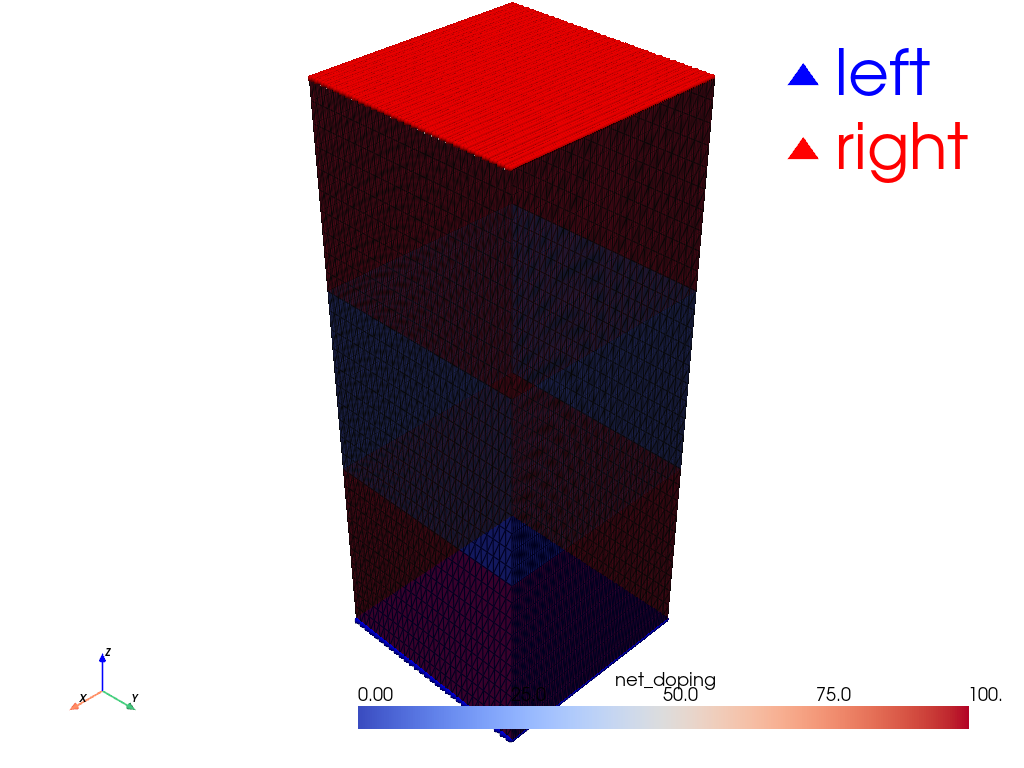

In [11]:
# Minimal visualization: mesh + net doping + BC markers
import pyvista as pv
from dolfinx import plot

# Build VTK grid from mesh topology
topo, cell_types, geom = plot.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topo, cell_types, geom)

# Attach cell-wise net doping (trim if needed)
grid.cell_data["net_doping"] = np.asarray(net_doping[: grid.n_cells], dtype=float)

# Boundary facet midpoints for markers (z-faces)
left_mid = mesh.compute_midpoints(domain, fdim, left_facets)
right_mid = mesh.compute_midpoints(domain, fdim, right_facets)

p = pv.Plotter()
p.add_mesh(grid, scalars="net_doping", show_edges=True, cmap="coolwarm", opacity=0.85)
p.add_points(left_mid, color="blue", point_size=7, render_points_as_spheres=True, label="left")
p.add_points(right_mid, color="red", point_size=7, render_points_as_spheres=True, label="right")
p.add_legend()
p.show_axes()
p.show()

# Solver

## initial poisson solve

In [12]:
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from dolfinx import geometry as dfx_geom_solver

Nc = 2.8e25 * (2.0 / np.sqrt(np.pi))   # m^-3
Nv = 1.04e25 * (2.0 / np.sqrt(np.pi))  # m^-3
kbT = V_0  # 0.026 eV at 300 K

Ec_ref = Ec0 - Ef0
Ev_ref = Ev0 - Ef0 

def _FD_half(x):
    """Fermi-Dirac integral of order 1/2.
    Ref: http://dx.doi.org/10.1063/1.4825209
    """
    v = x**4 + 50 + 33.6 * x * (1 - 0.68 * np.exp(-0.17 * (x + 1)**2))
    return 1.0 / (np.exp(-x) + (3.0 * np.pi**0.5 / 4.0) * v**(-3.0 / 8.0))

def get_semiclassical_charge(psi_norm, Nd_phys, Na_phys):
    """Compute normalized charge density from normalized potential ψ = φ/V₀.

    Parameters
    ----------
    psi_norm : float or array  –  φ / V₀ (dimensionless)
    Nd_phys, Na_phys : float or array  –  physical doping (m⁻³)

    Returns
    -------
    rho_norm : (p - n + Nd - Na) / N₀
    n_phys   : electron concentration (m⁻³)
    p_phys   : hole concentration (m⁻³)
    """
    psi_eV = psi_norm * V_0

    # Shifted band edges (Ef = 0)
    Ec_eff = Ec_ref - psi_eV
    Ev_eff = Ev_ref - psi_eV

    # Reduced Fermi energies
    eta_e = -Ec_eff / kbT        # (Ef − Ec_eff) / kT
    eta_h =  Ev_eff / kbT        # (Ev_eff − Ef) / kT

    n = Nc * _FD_half(eta_e)
    p = Nv * _FD_half(eta_h)

    rho_norm = (p - n + Nd_phys - Na_phys) / N_0
    return rho_norm, n, p


In [13]:

bcs_poisson = [bc_left, bc_right]

eps_rel = fem.Function(Q)
eps_rel.x.array[:] = eps_si_rel

u_psi = ufl.TrialFunction(V)
v_psi = ufl.TestFunction(V)

a_poisson = ufl.inner(eps_rel * ufl.grad(u_psi), ufl.grad(v_psi)) * ufl.dx
L_poisson = fem.Constant(domain, default_scalar_type(0.0)) * v_psi * ufl.dx

problem_init = LinearProblem(
    a_poisson, L_poisson, bcs=bcs_poisson,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="laplace_initial_presolve",
)
phi_init = problem_init.solve()
phi_init.name = "psi_laplace"

print(f"Laplace solve done.  ψ range: [{phi_init.x.array.min():.4f}, {phi_init.x.array.max():.4f}]")
print(f"Potential range: [{phi_init.x.array.min()*V_0:.4f}, {phi_init.x.array.max()*V_0:.4f}] V")

Laplace solve done.  ψ range: [23.0259, 26.8720]
Potential range: [0.5987, 0.6987] V


In [14]:
phi_poisson = fem.Function(V)
phi_poisson.x.array[:] = phi_init.x.array.copy()

rho_func  = fem.Function(Q)
drho_func = fem.Function(Q)

Nd_phys_cells = np.zeros(num_local_cells, dtype=float)
Nd_phys_cells[is_source] = Nd_physical_val
Nd_phys_cells[is_drain]  = Nd_physical_val
Na_phys_cells = np.zeros(num_local_cells, dtype=float)  # zero for n-i-n

max_iter   = 500
tol        = 1e-6
max_update = 1.0   # clamp step (normalized units)

print("Starting nonlinear Poisson iteration ...")
for it in range(max_iter):
    phi_vals = phi_poisson.eval(mids, all_cells)[:, 0]
    rho_vals, n_phys, p_phys = get_semiclassical_charge(
        phi_vals, Nd_phys_cells, Na_phys_cells
    )
    drho_vals = -(n_phys + p_phys) / N_0          # dρ_norm / dψ

    rho_func.x.array[:]  = rho_vals
    drho_func.x.array[:] = drho_vals


    a_gummel = (
        a_poisson
        - poisson_coeff * drho_func * u_psi * v_psi * ufl.dx
    )
    L_gummel = (
        poisson_coeff * (rho_func - drho_func * phi_poisson) * v_psi * ufl.dx
    )

    problem_nl = LinearProblem(
        a_gummel, L_gummel, bcs=bcs_poisson,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix="nonlinear_initial_presolve",
    )
    phi_new = problem_nl.solve()

    delta = phi_new.x.array - phi_poisson.x.array
    error = float(np.max(np.abs(delta)))

    phi_poisson.x.array[:] += np.clip(delta, -max_update, max_update)

    if it % 20 == 0 or error < tol:
        print(f"  Iter {it+1:4d}: max |Δψ| = {error:.4e}")

    if error < tol:
        print(f"Converged in {it+1} iterations!")
        break
else:
    print(f"WARNING: did not converge (final error = {error:.4e})")

phi_phys_min = phi_poisson.x.array.min() * V_0
phi_phys_max = phi_poisson.x.array.max() * V_0
print(f"Potential range: [{phi_phys_min:.4f}, {phi_phys_max:.4f}] V")

Starting nonlinear Poisson iteration ...
  Iter    1: max |Δψ| = 1.5173e+00
  Iter    3: max |Δψ| = 1.9540e-13
Converged in 3 iterations!
Potential range: [0.5987, 0.7118] V


In [15]:
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0, z_dim, 200)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding  = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])
pts_ok = np.array(pts_ok)

psi_line   = phi_poisson.eval(pts_ok, cells_ok).flatten()
phi_line_V = psi_line * V_0
z_line     = pts_ok[:, 2]


## first NEGF iteration

In [18]:
# Hamiltonian update from current Poisson potential
phi_atom = translator.fem_to_atom(phi_poisson)
phi_orb = translator.atoms_to_orbitals(phi_atom)

H_device_biased = np.array(H_device, copy=True)
diag_idx = np.diag_indices(H_device_biased.shape[0])

H_device_biased[diag_idx] = H_device_biased[diag_idx] - (phi_orb * V_0) - Ef0

print(f"H_device_biased ready: shape={H_device_biased.shape}, dtype={H_device_biased.dtype}")
print(f"Potential mapped to orbitals: min={(phi_orb * V_0).min():.4e} eV, max={(phi_orb * V_0).max():.4e} eV")

print(Ef0)

H_device_biased ready: shape=(640, 640), dtype=complex128
Potential mapped to orbitals: min=5.9867e-01 eV, max=7.1172e-01 eV
-4.3175


In [19]:
# Precompute Sancho-Rubio self-energies on real-energy grid (and optional contour grid)
import os
from concurrent.futures import ProcessPoolExecutor

_eta = 1e-6
_damp = 1e-9j
_tol = 1e-12

mu_left =  float(V_applied_left)
mu_right = float(V_applied_right)
E_grid = np.linspace(min(V_applied_left,V_applied_right), max(V_applied_left,V_applied_right) + 6, 501)
def _sigma_for_energy(args):
    i, E = args
    E = float(E)
    sigL = sancho_rubio_iterative_greens_function(
        E - mu_left,
        h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=_damp, nconv=_tol,
    )
    sigR = sancho_rubio_iterative_greens_function(
        E - mu_right,
        h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=_damp, nconv=_tol,
    )
    return i, sigL, sigR

nE = len(E_grid)
sigma_L_cache = [None] * nE
sigma_R_cache = [None] * nE

max_workers = min(max(1, (os.cpu_count() or 1) - 1), nE)
try:
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        for i, sigL, sigR in pool.map(_sigma_for_energy, list(enumerate(E_grid))):
            sigma_L_cache[i] = sigL
            sigma_R_cache[i] = sigR
except Exception as exc:
    print(f"Parallel sigma precompute fallback to serial due to: {exc}")
    for i, E in enumerate(E_grid):
        _, sigL, sigR = _sigma_for_energy((i, E))
        sigma_L_cache[i] = sigL
        sigma_R_cache[i] = sigR

print(f"Sigma cache ready on real grid: {nE} energies")

Sigma cache ready on real grid: 501 energies


In [20]:
# Charge density from cached self-energies: split into equilibrium + nonequilibrium
import os
from concurrent.futures import ProcessPoolExecutor
import negf.gf.recursive_greens_functions as rgf

kbT_eff = 0.025851999786435
mu_eq = mu_left  # left lead as equilibrium reference
print(f"C++ recursive available: {rgf._cpp_recursive is not None}")

def _fd(E, mu, kT):
    x = (E - mu) / max(kT, 1e-12)
    x = np.clip(x, -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

def _charge_contrib(i):
    from negf.gf.recursive_greens_functions import _recursive_inverse
    E = float(E_grid[i])
    sigL = sigma_L_cache[i]
    sigR = sigma_R_cache[i]

    fL = _fd(E, mu_left, kbT_eff)
    fR = _fd(E, mu_right, kbT_eff)
    fEq = _fd(E, mu_eq, kbT_eff)

    out_tot = _recursive_inverse(
        E,
        H_device_biased,
        sigL,
        sigR,
        compute_lesser=True,
        occ_left=fL,
        occ_right=fR,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=False,
        return_diag=True,
        return_gamma=True,
    )
    g_less_tot = np.asarray(out_tot[1])

    out_eq = _recursive_inverse(
        E,
        H_device_biased,
        sigL,
        sigR,
        compute_lesser=True,
        occ_left=fEq,
        occ_right=fEq,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=False,
        return_diag=True,
        return_gamma=True,
    )
    g_less_eq = np.asarray(out_eq[1])

    pref = 1.0 / (2.0 * np.pi)
    nE_tot = np.real(g_less_tot) * pref
    nE_eq = np.real(g_less_eq) * pref
    return i, nE_eq, (nE_tot - nE_eq)

dE = np.gradient(np.asarray(E_grid, dtype=float))
n_orb = H_device_biased.shape[0]
rho_eq_orb = np.zeros(n_orb, dtype=float)
rho_neq_orb = np.zeros(n_orb, dtype=float)

max_workers = min(max(1, (os.cpu_count() or 1) - 1), len(E_grid))
try:
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        for i, nE_eq, nE_neq in pool.map(_charge_contrib, range(len(E_grid))):
            w = dE[i]
            rho_eq_orb += nE_eq * w
            rho_neq_orb += nE_neq * w
except Exception as exc:
    print(f"Parallel charge integration fallback to serial due to: {exc}")
    for i in range(len(E_grid)):
        _, nE_eq, nE_neq = _charge_contrib(i)
        w = dE[i]
        rho_eq_orb += nE_eq * w
        rho_neq_orb += nE_neq * w

rho_tot_orb = rho_eq_orb + rho_neq_orb

rho_eq_atom = translator.orbitals_to_atoms(rho_eq_orb)
rho_neq_atom = translator.orbitals_to_atoms(rho_neq_orb)
rho_tot_atom = translator.orbitals_to_atoms(rho_tot_orb)

print("Charge integration complete")
print(f"rho_eq_atom  range: [{rho_eq_atom.min():.4e}, {rho_eq_atom.max():.4e}]")
print(f"rho_neq_atom range: [{rho_neq_atom.min():.4e}, {rho_neq_atom.max():.4e}]")
print(f"rho_tot_atom range: [{rho_tot_atom.min():.4e}, {rho_tot_atom.max():.4e}]")

C++ recursive available: False
Charge integration complete
rho_eq_atom  range: [1.0272e-05, 4.9233e-02]
rho_neq_atom range: [-4.1867e-02, -2.5436e-08]
rho_tot_atom range: [4.5043e-06, 2.9453e-02]


Mapped first-run charge to FEM grid
FEM charge range: [9.3643e-06, 2.4939e-02]


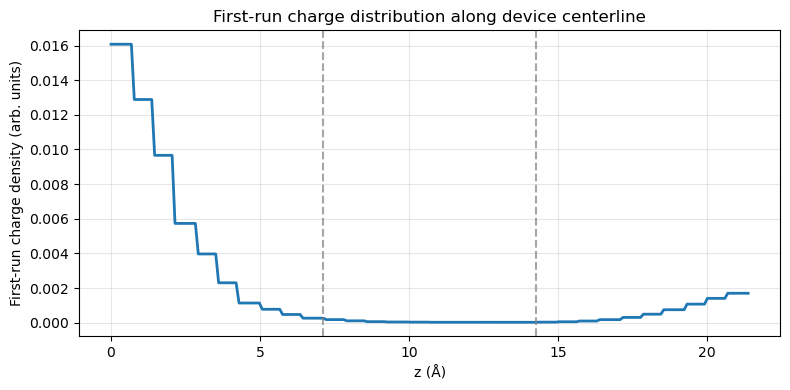

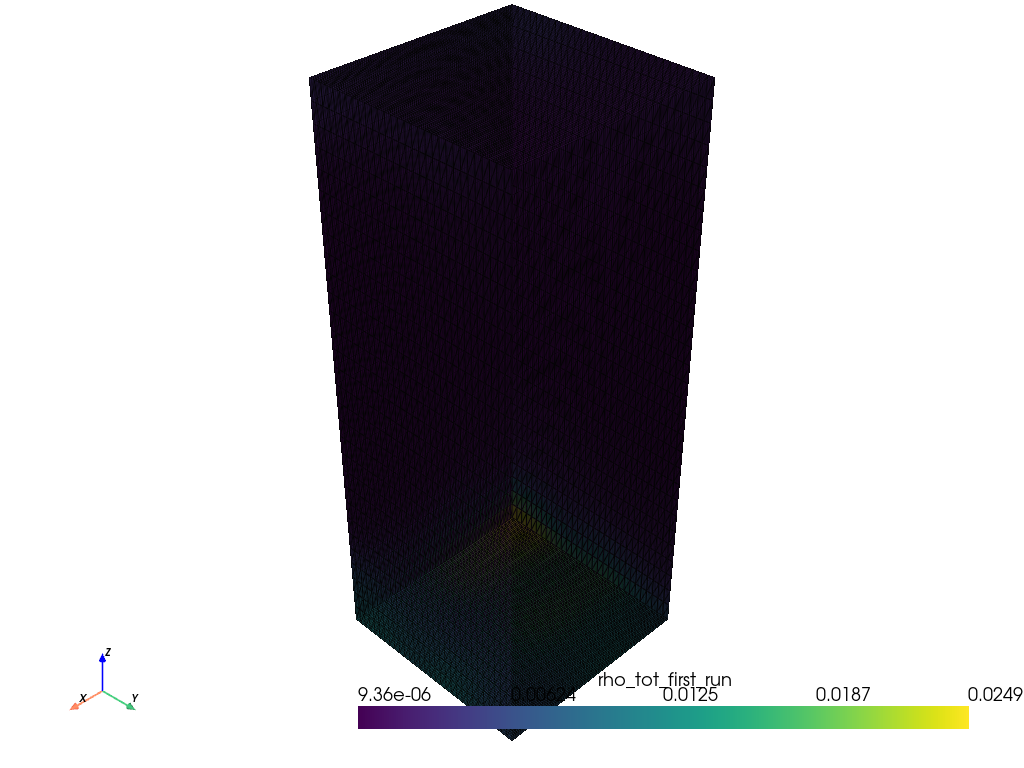

In [21]:
# Map first-run atomistic charge to FEM grid and visualize through the device
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from dolfinx import plot as dfx_plot

# 1) atom -> FEM (DG0 cell values)
rho_tot_fem_cells = translator.atom_to_fem(rho_tot_atom)

rho_tot_fem = fem.Function(Q)
rho_tot_fem.name = "rho_tot_first_run"
rho_tot_fem.x.array[:] = np.asarray(rho_tot_fem_cells[:len(rho_tot_fem.x.array)], dtype=default_scalar_type)

print("Mapped first-run charge to FEM grid")
print(f"FEM charge range: [{rho_tot_fem.x.array.min():.4e}, {rho_tot_fem.x.array.max():.4e}]")

# 2) 1D profile through device center (z-direction)
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 220)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.array(pts_ok)
rho_line = rho_tot_fem.eval(pts_ok, cells_ok).flatten()
z_line = pts_ok[:, 2]

plt.figure(figsize=(8, 4))
plt.plot(z_line, rho_line, lw=2)
plt.axvline(z_source_end, color="gray", ls="--", alpha=0.7)
plt.axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
plt.xlabel("z (Å)")
plt.ylabel("First-run charge density (arb. units)")
plt.title("First-run charge distribution along device centerline")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) 3D FEM visualization
topo, cell_types, geom = dfx_plot.vtk_mesh(domain, domain.topology.dim)
grid_rho = pv.UnstructuredGrid(topo, cell_types, geom)
grid_rho.cell_data["rho_tot_first_run"] = np.asarray(rho_tot_fem.x.array[: grid_rho.n_cells], dtype=float)

p = pv.Plotter()
p.add_mesh(grid_rho, scalars="rho_tot_first_run", show_edges=True, cmap="viridis", opacity=0.9)
p.add_axes()
p.show()

## Full gummel solve

In [47]:
# NEGF-Poisson Gummel loop (slow mixed potential updates + light debug toggle)
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
import negf.gf.recursive_greens_functions as rgf
from dolfinx.fem.petsc import LinearProblem

# ---- user-tunable controls ----
gummel_max_iter = 800
gummel_tol_phi = 1e-4
mix_phi = 0.25          # slow update
max_delta_phi = 0.25    # clamp in normalized units
_eta_loop = 1e-6

# Light-mode toggle for quick iteration/debug
light_mode = False
light_energy_stride = 1         # keep every Nth energy point
light_max_workers = 20
light_max_iter = 20
light_skip_fd_jacobian = True    # True: skip 2nd NEGF solve for drho/dphi

# keep recursive path deterministic in notebook/kernel workers
rgf._cpp_recursive = None

def _fd_loop(E, mu, kT):
    x = (E - mu) / max(kT, 1e-12)
    x = np.clip(x, -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

# initial guess to Poisson is old phi
phi_gummel = fem.Function(V)
if "phi_new" in globals():
    phi_gummel.x.array[:] = phi_new.x.array.copy()
else:
    phi_gummel.x.array[:] = phi_poisson.x.array.copy()

rho_negf_fem = fem.Function(Q)
drho_negf_fem = fem.Function(Q)

# finite-difference sensitivity step for d(rho)/d(phi) in Gummel linearization
dphi_fd = 0.02

# Convert NEGF electron occupancy -> normalized volumetric mobile charge
# rho_norm uses sign convention: (p - n + Nd - Na)/N0, so electron contribution is negative
box_vol_m3 = (x_dim * L_0) * (y_dim * L_0) * (z_dim * L_0)
atom_vol_m3 = box_vol_m3 / max(int(translator.n_atoms), 1)
atom_norm_scale = atom_vol_m3 * N_0
rho_fixed_cells_norm = np.asarray(
    (Nd_norm.x.array.real - Na_norm.x.array.real)[:len(rho_negf_fem.x.array)],
    dtype=float,
)

# prepare loop energy grid/cache view
if light_mode:
    loop_idx = np.arange(0, len(E_grid), light_energy_stride, dtype=int)
    E_grid_loop = np.asarray(E_grid[loop_idx], dtype=float)
    sigma_L_loop = [sigma_L_cache[i] for i in loop_idx]
    sigma_R_loop = [sigma_R_cache[i] for i in loop_idx]
    gummel_iter_use = min(gummel_max_iter, light_max_iter)
else:
    loop_idx = np.arange(len(E_grid), dtype=int)
    E_grid_loop = np.asarray(E_grid, dtype=float)
    sigma_L_loop = sigma_L_cache
    sigma_R_loop = sigma_R_cache
    gummel_iter_use = gummel_max_iter

print("Starting NEGF-Poisson Gummel loop...")
print(f"light_mode={light_mode}, nE_loop={len(E_grid_loop)}, mix_phi={mix_phi}, tol={gummel_tol_phi}, max_iter={gummel_iter_use}")
print(f"atom_norm_scale = {atom_norm_scale:.3e} (m^3 * N0)")

for g_it in range(gummel_iter_use):
    # 1) Update Hamiltonian from current mixed potential
    phi_atom_loop = translator.fem_to_atom(phi_gummel)
    phi_orb_loop = translator.atoms_to_orbitals(phi_atom_loop)

    H_device_biased = np.array(H_device, copy=True)
    diag_idx = np.diag_indices(H_device_biased.shape[0])
    H_device_biased[diag_idx] = H_device_biased[diag_idx] - (phi_orb_loop * V_0) - Ef0

    # NEGF charge at current potential
    kbT_eff = float(kbT) if "kbT" in globals() else 0.025851999786435
    mu_eq = mu_left
    dE_loop = np.gradient(E_grid_loop)

    n_orb = H_device_biased.shape[0]
    rho_eq_orb = np.zeros(n_orb, dtype=float)
    rho_neq_orb = np.zeros(n_orb, dtype=float)

    def _charge_contrib_loop(i_loop):
        from negf.gf.recursive_greens_functions import _recursive_inverse
        E = float(E_grid_loop[i_loop])
        sigL = sigma_L_loop[i_loop]
        sigR = sigma_R_loop[i_loop]

        fL = _fd_loop(E, mu_left, kbT_eff)
        fR = _fd_loop(E, mu_right, kbT_eff)
        fEq = _fd_loop(E, mu_eq, kbT_eff)

        out_tot = _recursive_inverse(
            E, H_device_biased, sigL, sigR,
            compute_lesser=True,
            occ_left=fL, occ_right=fR,
            overlap_matrix=S_device,
            eta=_eta_loop,
            return_trace=False,
            return_diag=True,
            return_gamma=True,
        )
        out_eq = _recursive_inverse(
            E, H_device_biased, sigL, sigR,
            compute_lesser=True,
            occ_left=fEq, occ_right=fEq,
            overlap_matrix=S_device,
            eta=_eta_loop,
            return_trace=False,
            return_diag=True,
            return_gamma=True,
        )

        g_less_tot = np.asarray(out_tot[1])
        g_less_eq = np.asarray(out_eq[1])

        pref = 1.0 / (2.0 * np.pi)
        nE_tot = np.real(g_less_tot) * pref
        nE_eq = np.real(g_less_eq) * pref
        return i_loop, nE_eq, (nE_tot - nE_eq)

    max_workers = 16
    if light_mode:
        max_workers = min(max_workers, light_max_workers)

    try:
        with ProcessPoolExecutor(max_workers=max_workers) as pool:
            for i_loop, nE_eq, nE_neq in pool.map(_charge_contrib_loop, range(len(E_grid_loop))):
                w = dE_loop[i_loop]
                rho_eq_orb += nE_eq * w
                rho_neq_orb += nE_neq * w
    except Exception as exc:
        print(f"  Parallel NEGF charge fallback to serial due to: {exc}")
        for i_loop in range(len(E_grid_loop)):
            _, nE_eq, nE_neq = _charge_contrib_loop(i_loop)
            w = dE_loop[i_loop]
            rho_eq_orb += nE_eq * w
            rho_neq_orb += nE_neq * w

    rho_tot_orb = rho_eq_orb + rho_neq_orb
    rho_tot_atom = translator.orbitals_to_atoms(rho_tot_orb)

    # Convert to normalized mobile charge density and add fixed ionic charge
    rho_mobile_atom_norm = -rho_tot_atom / max(atom_norm_scale, 1e-30)
    rho_mobile_cells = np.asarray(translator.atom_to_fem(rho_mobile_atom_norm), dtype=float)
    rho_cells_total = rho_mobile_cells + rho_fixed_cells_norm

    # mobile + fixed charge used in Poisson RHS
    rho_negf_fem.x.array[:] = np.asarray(
        rho_cells_total[:len(rho_negf_fem.x.array)],
        dtype=default_scalar_type,
    )

    # Poisson linearization term d(rho_mobile)/d(phi)
    if light_mode and light_skip_fd_jacobian:
        drho_negf_fem.x.array[:] = 0.0
    else:
        phi_gummel_pert = fem.Function(V)
        phi_gummel_pert.x.array[:] = phi_gummel.x.array + dphi_fd

        phi_atom_pert = translator.fem_to_atom(phi_gummel_pert)
        phi_orb_pert = translator.atoms_to_orbitals(phi_atom_pert)

        H_device_pert = np.array(H_device, copy=True)
        H_device_pert[diag_idx] = H_device_pert[diag_idx] - (phi_orb_pert * V_0) - Ef0

        rho_eq_orb_pert = np.zeros(n_orb, dtype=float)
        rho_neq_orb_pert = np.zeros(n_orb, dtype=float)

        def _charge_contrib_loop_pert(i_loop):
            from negf.gf.recursive_greens_functions import _recursive_inverse
            E = float(E_grid_loop[i_loop])
            sigL = sigma_L_loop[i_loop]
            sigR = sigma_R_loop[i_loop]

            fL = _fd_loop(E, mu_left, kbT_eff)
            fR = _fd_loop(E, mu_right, kbT_eff)
            fEq = _fd_loop(E, mu_eq, kbT_eff)

            out_tot = _recursive_inverse(
                E, H_device_pert, sigL, sigR,
                compute_lesser=True,
                occ_left=fL, occ_right=fR,
                overlap_matrix=S_device,
                eta=_eta_loop,
                return_trace=False,
                return_diag=True,
                return_gamma=True,
            )
            out_eq = _recursive_inverse(
                E, H_device_pert, sigL, sigR,
                compute_lesser=True,
                occ_left=fEq, occ_right=fEq,
                overlap_matrix=S_device,
                eta=_eta_loop,
                return_trace=False,
                return_diag=True,
                return_gamma=True,
            )

            g_less_tot = np.asarray(out_tot[1])
            g_less_eq = np.asarray(out_eq[1])

            pref = 1.0 / (2.0 * np.pi)
            nE_tot = np.real(g_less_tot) * pref
            nE_eq = np.real(g_less_eq) * pref
            return i_loop, nE_eq, (nE_tot - nE_eq)

        try:
            with ProcessPoolExecutor(max_workers=max_workers) as pool:
                for i_loop, nE_eq, nE_neq in pool.map(_charge_contrib_loop_pert, range(len(E_grid_loop))):
                    w = dE_loop[i_loop]
                    rho_eq_orb_pert += nE_eq * w
                    rho_neq_orb_pert += nE_neq * w
        except Exception:
            for i_loop in range(len(E_grid_loop)):
                _, nE_eq, nE_neq = _charge_contrib_loop_pert(i_loop)
                w = dE_loop[i_loop]
                rho_eq_orb_pert += nE_eq * w
                rho_neq_orb_pert += nE_neq * w

        rho_tot_atom_pert = translator.orbitals_to_atoms(rho_eq_orb_pert + rho_neq_orb_pert)
        rho_mobile_atom_norm_pert = -rho_tot_atom_pert / max(atom_norm_scale, 1e-30)
        rho_mobile_cells_pert = np.asarray(translator.atom_to_fem(rho_mobile_atom_norm_pert), dtype=float)
        drho_cells = (rho_mobile_cells_pert - rho_mobile_cells) / dphi_fd
        # Prevent the Jacobian from causing matrix paralysis
        drho_cells = np.clip(drho_cells, -50.0, 0.0) # Tune this floor value
        drho_negf_fem.x.array[:] = np.asarray(
            drho_cells[:len(drho_negf_fem.x.array)],
            dtype=default_scalar_type,
        )

    a_gummel_negf = (
        a_poisson - poisson_coeff * drho_negf_fem * u_psi * v_psi * ufl.dx
    )
    L_gummel_negf = (
        poisson_coeff * (rho_negf_fem - drho_negf_fem * phi_gummel) * v_psi * ufl.dx
    )

    # solve
    problem_negf_poisson = LinearProblem(
        a_gummel_negf, L_gummel_negf, bcs=bcs_poisson,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix=f"negf_poisson_gummel_{g_it}",
    )
    phi_candidate = problem_negf_poisson.solve()

    # mixed potential update
    delta_phi = phi_candidate.x.array - phi_gummel.x.array
    delta_phi = np.clip(delta_phi, -max_delta_phi, max_delta_phi)
    phi_next = phi_gummel.x.array + mix_phi * delta_phi

    err_phi = float(np.max(np.abs(phi_next - phi_gummel.x.array)))
    phi_gummel.x.array[:] = phi_next

    # Keep canonical variables updated
    phi_new = fem.Function(V)
    phi_new.x.array[:] = phi_gummel.x.array
    phi_poisson.x.array[:] = phi_gummel.x.array

    # Update Hamiltonian after new potential update
    phi_atom_loop = translator.fem_to_atom(phi_gummel)
    phi_orb_loop = translator.atoms_to_orbitals(phi_atom_loop)
    H_device_biased[diag_idx] = H_device[diag_idx] - (phi_orb_loop * V_0) - Ef0

    bc_drop_norm = abs(float(psi_left_norm - psi_right_norm))
    charge_drive_est = float((poisson_coeff / max(eps_si_rel, 1e-30)) * np.max(np.abs(rho_cells_total)))
    print(
        f"  Gummel {g_it+1:03d}: solved Poisson, |Δphi|_max={err_phi:.3e}, "
        f"rho_mobile=[{rho_mobile_cells.min():.3e}, {rho_mobile_cells.max():.3e}], "
        f"rho_total=[{rho_cells_total.min():.3e}, {rho_cells_total.max():.3e}], "
        f"BCdrop={bc_drop_norm:.3e}, charge_drive~{charge_drive_est:.3e}"
    )

    if err_phi < gummel_tol_phi:
        print(f"Converged in {g_it+1} Gummel iterations")
        break
else:
    print("Reached max Gummel iterations without full convergence")

print(
    f"Final mixed potential range (normalized): "
    f"[{phi_gummel.x.array.min():.4e}, {phi_gummel.x.array.max():.4e}]"
 )
print("Hamiltonian updated from final mixed potential (H_device_biased ready).")

Starting NEGF-Poisson Gummel loop...
light_mode=False, nE_loop=501, mix_phi=0.25, tol=0.0001, max_iter=800
atom_norm_scale = 1.116e-05 (m^3 * N0)
  Gummel 001: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.236e+03, -8.425e-01], rho_total=[-2.136e+03, 9.807e+01], BCdrop=3.846e+00, charge_drive~1.276e+00
  Gummel 002: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.233e+03, -8.355e-01], rho_total=[-2.133e+03, 9.808e+01], BCdrop=3.846e+00, charge_drive~1.274e+00
  Gummel 003: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.229e+03, -8.287e-01], rho_total=[-2.129e+03, 9.808e+01], BCdrop=3.846e+00, charge_drive~1.272e+00
  Gummel 004: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.226e+03, -8.220e-01], rho_total=[-2.126e+03, 9.809e+01], BCdrop=3.846e+00, charge_drive~1.270e+00
  Gummel 005: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.222e+03, -8.155e-01], rho_total=[-2.122e+03, 9.810e+01], BCdrop=3.846e+00, charge_drive~1.268e+00
  Gummel 006: solved Poisson,

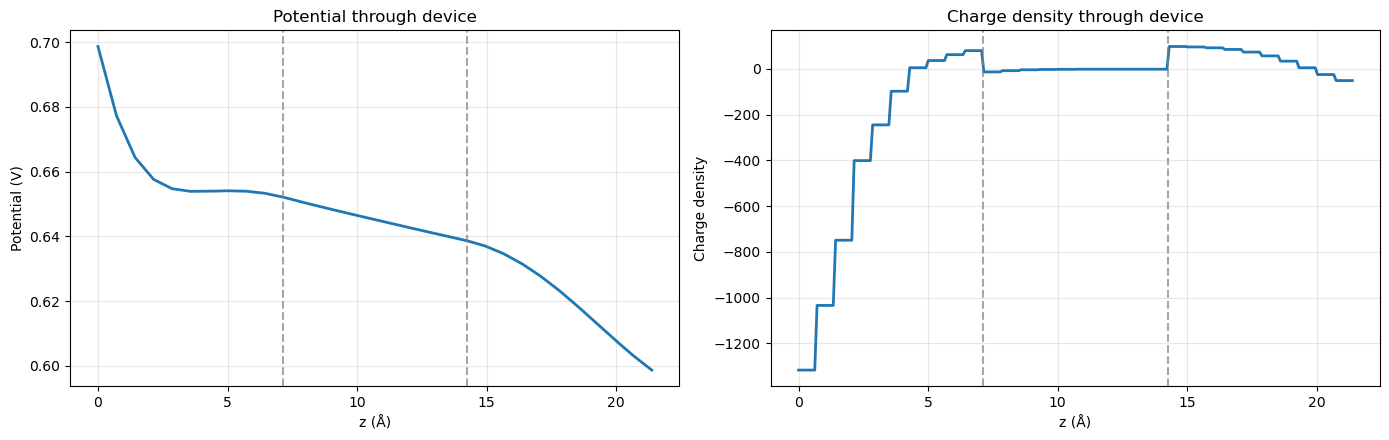

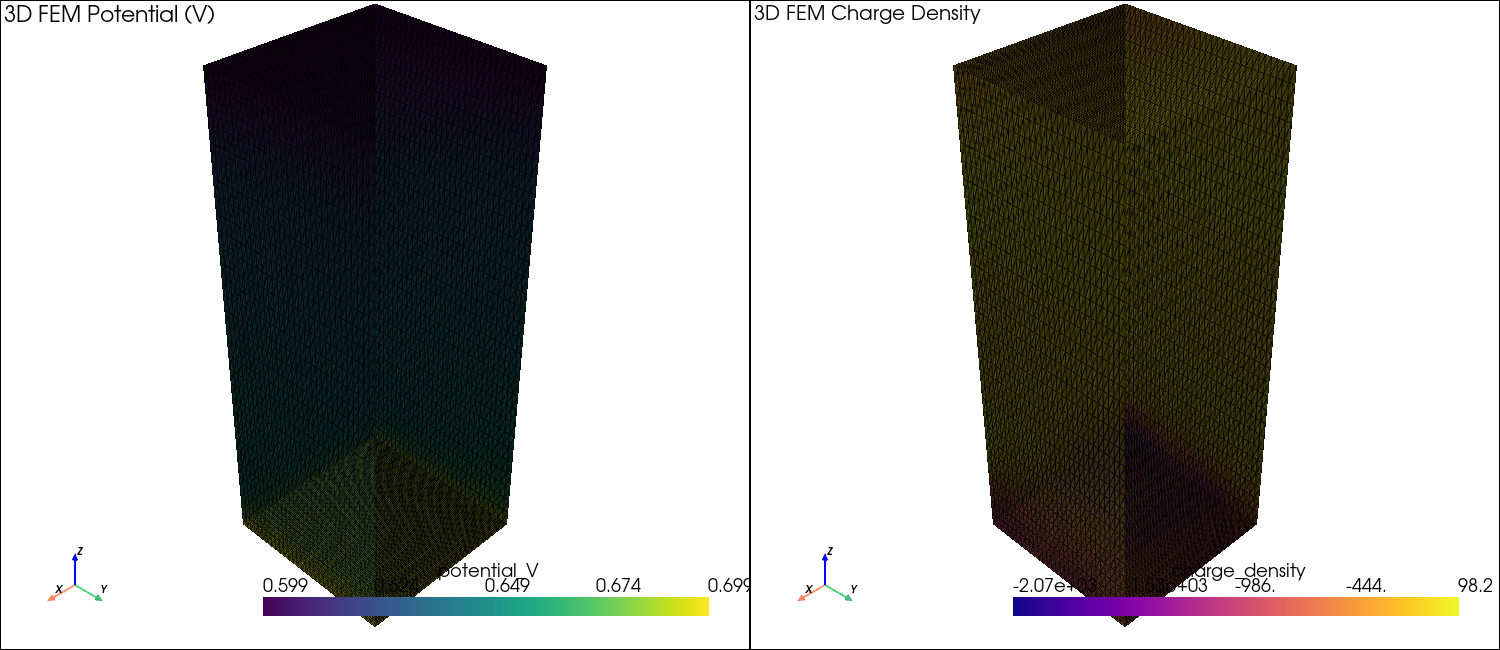

Potential range (V): [5.9867e-01, 6.9867e-01]
Charge range (DG0): [-2.0708e+03, 9.8194e+01]


In [50]:
# Post-Gummel visualization: potential + charge along device and 3D FEM views
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from dolfinx import plot as dfx_plot

# pick latest potential solution
if "phi_gummel" in globals():
    phi_plot = phi_gummel
elif "phi_new" in globals():
    phi_plot = phi_new
else:
    phi_plot = phi_poisson

# pick/latest build charge function on DG0
if "rho_negf_fem" in globals():
    rho_plot = rho_negf_fem
elif "rho_tot_fem" in globals():
    rho_plot = rho_tot_fem
else:
    rho_plot = fem.Function(Q)
    if "rho_tot_atom" in globals():
        _rho_cells = translator.atom_to_fem(rho_tot_atom)
        rho_plot.x.array[:] = np.asarray(_rho_cells[:len(rho_plot.x.array)], dtype=default_scalar_type)
    else:
        rho_plot.x.array[:] = 0.0

# ----- 1D centerline profiles along z -----
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 240)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.asarray(pts_ok)
z_line = pts_ok[:, 2]
phi_line = phi_plot.eval(pts_ok, cells_ok).flatten() * V_0
rho_line = rho_plot.eval(pts_ok, cells_ok).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(z_line, phi_line, lw=2)
axes[0].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[0].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[0].set_xlabel("z (Å)")
axes[0].set_ylabel("Potential (V)")
axes[0].set_title("Potential through device")
axes[0].grid(alpha=0.3)

axes[1].plot(z_line, rho_line, lw=2)
axes[1].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[1].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("z (Å)")
axes[1].set_ylabel("Charge density")
axes[1].set_title("Charge density through device")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----- 3D FEM views -----
topo, cell_types, geom = dfx_plot.vtk_mesh(domain, domain.topology.dim)
grid3d = pv.UnstructuredGrid(topo, cell_types, geom)

# potential is point-wise (CG1), charge is cell-wise (DG0)
grid3d.point_data["potential_V"] = np.asarray(phi_plot.x.array, dtype=float) * V_0
grid3d.cell_data["charge_density"] = np.asarray(rho_plot.x.array[:grid3d.n_cells], dtype=float)

pl = pv.Plotter(shape=(1, 2), window_size=(1500, 650))
pl.subplot(0, 0)
pl.add_text("3D FEM Potential (V)", font_size=11)
pl.add_mesh(grid3d, scalars="potential_V", cmap="viridis", show_edges=True, opacity=0.95)
pl.add_axes()

pl.subplot(0, 1)
pl.add_text("3D FEM Charge Density", font_size=11)
pl.add_mesh(grid3d, scalars="charge_density", cmap="plasma", show_edges=True, opacity=0.95)
pl.add_axes()

pl.link_views()
pl.show()

print(f"Potential range (V): [{phi_line.min():.4e}, {phi_line.max():.4e}]")
print(f"Charge range (DG0): [{rho_plot.x.array.min():.4e}, {rho_plot.x.array.max():.4e}]")

In [49]:
# Current calculation using full sparse matrix Green's function (no recursive GF for transmission)
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy import constants as spc

# ---- controls ----
current_energy_stride = 1   # >1 for quick debug, 1 for full accuracy
use_phi_gummel_hamiltonian = True

if use_phi_gummel_hamiltonian and "phi_gummel" in globals():
    phi_atom_cur = translator.fem_to_atom(phi_gummel)
    phi_orb_cur = translator.atoms_to_orbitals(phi_atom_cur)
    H_for_current = np.array(H_device, copy=True)
    _diag = np.diag_indices(H_for_current.shape[0])
    H_for_current[_diag] = H_for_current[_diag] - (phi_orb_cur * V_0) - Ef0
else:
    H_for_current = H_device_biased

idx = np.arange(0, len(E_grid), current_energy_stride, dtype=int)
E_cur = np.asarray(E_grid[idx], dtype=float)
dE_cur = np.gradient(E_cur)

def _fd(E, mu, kT):
    x = np.clip((E - mu) / max(kT, 1e-12), -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

n_orb = H_for_current.shape[0]
eta_cur = _eta if "_eta" in globals() else 1e-6

# Static sparse operators
H_sp = sp.csr_matrix(H_for_current.astype(np.complex128))
S_sp = sp.csr_matrix(S_device.astype(np.complex128))
I_dense = np.eye(n_orb, dtype=np.complex128)

T_of_E = np.zeros(len(E_cur), dtype=float)
f_diff = np.zeros(len(E_cur), dtype=float)

for j, ii in enumerate(idx):
    E = float(E_grid[ii])
    sigL_blk = np.asarray(sigma_L_cache[ii], dtype=np.complex128)
    sigR_blk = np.asarray(sigma_R_cache[ii], dtype=np.complex128)

    # Build full sparse operator: A(E) = (E + iη)S - H - ΣL - ΣR
    A_sp = ((E + 1j * eta_cur) * S_sp - H_sp).tolil()
    A_sp[:nL, :nL] -= sigL_blk
    A_sp[-nL:, -nL:] -= sigR_blk
    A_sp = A_sp.tocsc()

    # Full inverse via sparse LU solve against identity
    lu = spla.splu(A_sp)
    G_full = lu.solve(I_dense)

    # Embed full lead self-energies and compute full Γ matrices
    Sigma_L_full = np.zeros((n_orb, n_orb), dtype=np.complex128)
    Sigma_R_full = np.zeros((n_orb, n_orb), dtype=np.complex128)
    Sigma_L_full[:nL, :nL] = sigL_blk
    Sigma_R_full[-nL:, -nL:] = sigR_blk

    Gamma_L_full = 1j * (Sigma_L_full - Sigma_L_full.conj().T)
    Gamma_R_full = 1j * (Sigma_R_full - Sigma_R_full.conj().T)

    # Standard full-matrix transmission expression
    prod = Gamma_L_full @ G_full @ Gamma_R_full @ G_full.conj().T
    T_val = np.real(np.trace(prod))
    T_of_E[j] = max(T_val, 0.0)

    fL = _fd(E, mu_left, kbT if "kbT" in globals() else 0.025851999786435)
    fR = _fd(E, mu_right, kbT if "kbT" in globals() else 0.025851999786435)
    f_diff[j] = fL - fR

# E is in eV, so dE_J = q * dE_eV -> prefactor (2 q^2 / h)
pref = 2.0 * (spc.elementary_charge ** 2) / spc.h
I_amp = pref * np.sum(T_of_E * f_diff * dE_cur)

print(f"Current (A): {I_amp:.6e}")
print(f"Current (uA): {I_amp*1e6:.6e}")
print(f"Current density proxy (A/um): {I_amp/1e6:.6e}")
print(f"Transmission range: [{T_of_E.min():.3e}, {T_of_E.max():.3e}]")

# quick diagnostic plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(E_cur, T_of_E, lw=1.5)
ax[0].set_xlabel("Energy (eV)")
ax[0].set_ylabel("T(E)")
ax[0].set_title("Transmission")
ax[0].grid(alpha=0.3)

ax[1].plot(E_cur, T_of_E * f_diff, lw=1.5)
ax[1].set_xlabel("Energy (eV)")
ax[1].set_ylabel("T(E) [fL-fR]")
ax[1].set_title("Current integrand")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 